# 01. Stable Diffusion 手写推理流水线

**规则**：禁止使用 `pipe(prompt)` 等高层 API。每一步都要自己写。

本 notebook 拆解 SD inference 为以下 6 步：
1. Tokenize prompt → token ids
2. Text encoder → text embeddings (77, 768)
3. Init noise → (4, 64, 64) latent
4. 50 步 DDIM 循环（每步：cond + uncond → CFG → DDIM step）
5. VAE decode → (3, 512, 512) image
6. Save

每一步都打印 tensor shape 和均值/方差，确认理解。

## 0. 准备：加载所有组件

SD 由四个独立 nn.Module 组成：
- CLIP tokenizer + text encoder
- UNet
- VAE (encoder + decoder)
- Scheduler（采样器，不是 nn.Module 但配置在此）

In [1]:
import os
from pathlib import Path
import json
import torch
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler

MODEL_ID = os.environ.get('P3_MODEL_ID', 'stable-diffusion-v1-5/stable-diffusion-v1-5')
MODEL_REVISION = os.environ.get('P3_MODEL_REVISION', '451f4fe16113bff5a5d2269ed5ad43b0592e9a14')
OUTPUT_DIR = Path(os.environ.get('P3_OUTPUT_DIR', 'outputs'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# 加载 4 个组件（注意 subfolder）
load_kwargs = {'revision': MODEL_REVISION} if MODEL_REVISION else {}
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", **load_kwargs)
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", **load_kwargs).to(device, dtype=dtype)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", **load_kwargs).to(device, dtype=dtype)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", **load_kwargs).to(device, dtype=dtype)
scheduler = DDIMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler", **load_kwargs)

# 全部切换到 eval 模式
text_encoder.eval(); vae.eval(); unet.eval()

print("✅ Loaded all 4 components")
print(f"  text_encoder params: {sum(p.numel() for p in text_encoder.parameters())/1e6:.1f}M")
print(f"  vae params:          {sum(p.numel() for p in vae.parameters())/1e6:.1f}M")
print(f"  unet params:         {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


✅ Loaded all 4 components
  text_encoder params: 123.1M
  vae params:          83.7M
  unet params:         859.5M


## 1. Tokenize

Prompt 经过 CLIP tokenizer 变成长度 77 的 token id 序列。
- BOS token: id 49406
- EOS token: id 49407
- 不足 77 用 49407 padding，超过会截断

In [2]:
prompt = "a photograph of an astronaut riding a horse on mars"
negative_prompt = "low quality, blurry, distorted"

# Tokenize positive prompt
text_input = tokenizer(
    prompt,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
)
print(f"input_ids.shape: {text_input.input_ids.shape}  (should be (1, 77))")
print(f"first 10 tokens: {text_input.input_ids[0][:10].tolist()}")
print(f"decoded: {tokenizer.decode(text_input.input_ids[0][:10])}")

# Tokenize negative prompt
uncond_input = tokenizer(
    negative_prompt, padding="max_length", max_length=77,
    truncation=True, return_tensors="pt",
)

input_ids.shape: torch.Size([1, 77])  (should be (1, 77))
first 10 tokens: [49406, 320, 8853, 539, 550, 18376, 6765, 320, 4558, 525]
decoded: <|startoftext|>a photograph of an astronaut riding a horse on


## 2. Text Encode

Token ids → text embeddings (1, 77, 768)。每个 token 都对应一个 768 维向量。

**关键事实**：所有 77 个 token embeddings 都会被 UNet 看到（不只是非 padding 部分）。

In [3]:
with torch.no_grad():
    cond_emb = text_encoder(text_input.input_ids.to(device))[0]
    uncond_emb = text_encoder(uncond_input.input_ids.to(device))[0]

print(f"cond_emb:   {cond_emb.shape}  mean={cond_emb.float().mean():.4f}, std={cond_emb.float().std():.4f}")
print(f"uncond_emb: {uncond_emb.shape}")

# concat for batched CFG
text_emb = torch.cat([uncond_emb, cond_emb], dim=0)
print(f"text_emb concat: {text_emb.shape}  (should be (2, 77, 768))")

cond_emb:   torch.Size([1, 77, 768])  mean=-0.1077, std=1.0146
uncond_emb: torch.Size([1, 77, 768])
text_emb concat: torch.Size([2, 77, 768])  (should be (2, 77, 768))


## 3. 初始化 latent

SD 1.5 的 latent shape 是 (1, 4, 64, 64)，对应 512×512 输出（8x 下采样）。

**重要**：要乘 `scheduler.init_noise_sigma`（DDIM 是 1.0，其他 sampler 可能不是）。

In [4]:
SEED = 42
torch.cuda.manual_seed_all(SEED) if torch.cuda.is_available() else None
torch.manual_seed(SEED)

height, width = 512, 512
latent_shape = (1, 4, height // 8, width // 8)
z = torch.randn(latent_shape, device=device, dtype=dtype)
z = z * scheduler.init_noise_sigma  # for DDIM=1.0, no-op

print(f"initial z: {z.shape}, range=[{z.float().min():.2f}, {z.float().max():.2f}]")

initial z: torch.Size([1, 4, 64, 64]), range=[-3.93, 3.93]


## 4. DDIM 采样循环

**核心**：每步做两次 UNet 前向（cond + uncond），CFG 线性外推，DDIM 更新。

通过 batch concat 优化为单次前向（输入 batch=2）。

In [5]:
NUM_STEPS = 50
CFG_SCALE = 7.5

scheduler.set_timesteps(NUM_STEPS)
print(f"timesteps: {scheduler.timesteps[:5]}, ..., {scheduler.timesteps[-5:]}")

from tqdm import tqdm
latent_stats = []
for step_index, t in enumerate(tqdm(scheduler.timesteps)):
    # Batch concat for CFG
    z_in = torch.cat([z, z], dim=0)  # (2, 4, 64, 64)
    z_in = scheduler.scale_model_input(z_in, t)  # 某些 sampler 需要 scaling
    
    # UNet 前向（一次性算两个）
    with torch.no_grad():
        eps = unet(z_in, t, encoder_hidden_states=text_emb).sample
    
    eps_uncond, eps_cond = eps.chunk(2)
    
    # CFG 外推
    eps = eps_uncond + CFG_SCALE * (eps_cond - eps_uncond)
    
    # DDIM step
    z = scheduler.step(eps, t, z).prev_sample
    if step_index in {0, 9, 24, 49}:
        latent_stats.append({'step': step_index, 'timestep': int(t), 'mean': float(z.float().mean()), 'std': float(z.float().std()), 'min': float(z.float().min()), 'max': float(z.float().max())})

print(f"final z: {z.shape}, range=[{z.float().min():.2f}, {z.float().max():.2f}]")

timesteps: tensor([981, 961, 941, 921, 901]), ..., tensor([81, 61, 41, 21,  1])


  0%|                                                    | 0/50 [00:00<?, ?it/s]

  2%|▉                                           | 1/50 [00:00<00:14,  3.36it/s]

 10%|████▍                                       | 5/50 [00:00<00:02, 15.17it/s]

 18%|███████▉                                    | 9/50 [00:00<00:01, 22.57it/s]

...

 76%|████████████████████████████████▋          | 38/50 [00:01<00:00, 37.38it/s]

 86%|████████████████████████████████████▉      | 43/50 [00:01<00:00, 38.63it/s]

 94%|████████████████████████████████████████▍  | 47/50 [00:01<00:00, 38.58it/s]

100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 31.99it/s]

final z: torch.Size([1, 4, 64, 64]), range=[-4.91, 5.95]


## 5. VAE Decode

Latent → image。注意要**除以 scaling factor**（SD 1.5 是 0.18215）。

Decoder 输出是 [-1, 1] 范围的 RGB tensor。

image: torch.Size([1, 3, 512, 512]), range=[-1.32, 1.30]


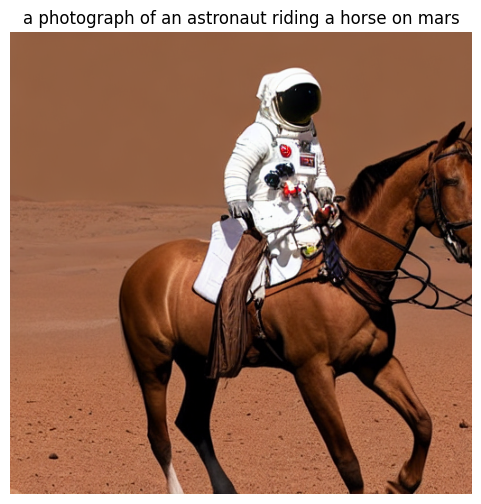

saved: outputs/manual/manual_sd_seed42.png


840

In [6]:
with torch.no_grad():
    z_decode = z / 0.18215  # SD 1.5 scaling factor
    image = vae.decode(z_decode).sample

print(f"image: {image.shape}, range=[{image.float().min():.2f}, {image.float().max():.2f}]")

# 转回 [0, 1] 范围
image = (image / 2 + 0.5).clamp(0, 1)

# 显示
import matplotlib.pyplot as plt
img_np = image[0].permute(1, 2, 0).float().cpu().numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.axis('off')
plt.title(prompt[:60])
output_image = OUTPUT_DIR / 'manual_sd_seed42.png'
plt.savefig(output_image, dpi=140, bbox_inches='tight')
plt.show()
print('saved:', output_image)
(OUTPUT_DIR / 'manual_sd_stats.json').write_text(json.dumps({'model_id': MODEL_ID, 'model_revision': MODEL_REVISION, 'seed': SEED, 'steps': NUM_STEPS, 'cfg': CFG_SCALE, 'latent_stats': latent_stats}, indent=2) + '\n', encoding='utf-8')

## 6. 封装成函数（参考）

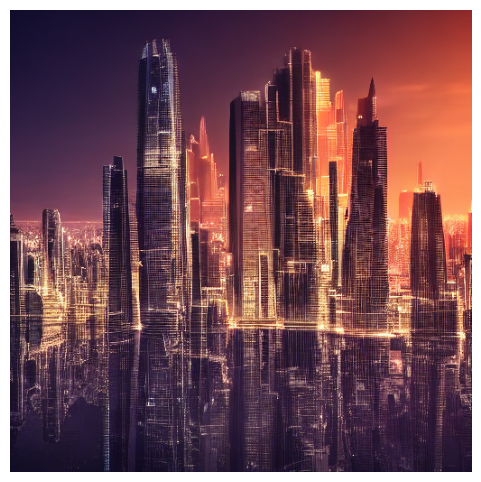

In [7]:
@torch.no_grad()
def my_sd_inference(prompt, negative_prompt="", num_steps=50, cfg=7.5, seed=None,
                    height=512, width=512):
    """我手写的 SD 推理，不依赖任何高层 API."""
    if seed is not None:
        torch.manual_seed(seed)
    
    # 1. Tokenize
    text_input = tokenizer(prompt, padding="max_length", max_length=77,
                            truncation=True, return_tensors="pt")
    uncond_input = tokenizer(negative_prompt, padding="max_length", max_length=77,
                              truncation=True, return_tensors="pt")
    
    # 2. Encode
    cond_emb = text_encoder(text_input.input_ids.to(device))[0]
    uncond_emb = text_encoder(uncond_input.input_ids.to(device))[0]
    text_emb = torch.cat([uncond_emb, cond_emb], dim=0)
    
    # 3. Init noise
    z = torch.randn((1, 4, height // 8, width // 8), device=device, dtype=dtype)
    z = z * scheduler.init_noise_sigma
    
    # 4. Sampling loop
    scheduler.set_timesteps(num_steps)
    for t in scheduler.timesteps:
        z_in = scheduler.scale_model_input(torch.cat([z, z], dim=0), t)
        eps = unet(z_in, t, encoder_hidden_states=text_emb).sample
        eps_u, eps_c = eps.chunk(2)
        eps = eps_u + cfg * (eps_c - eps_u)
        z = scheduler.step(eps, t, z).prev_sample
    
    # 5. Decode
    image = vae.decode(z / 0.18215).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    return image

# Test
img = my_sd_inference(
    prompt="a futuristic city skyline at sunset, cinematic lighting",
    seed=123,
    num_steps=30,
    cfg=7.5,
)
plt.figure(figsize=(6, 6))
plt.imshow(img[0].permute(1, 2, 0).float().cpu().numpy())
plt.axis('off')
plt.show()

## 思考题

1. 如果把 `cfg=0`（无 guidance），生成什么？为什么？
2. 如果只用 `cond_emb` 不做 batch concat，结果会怎样？（提示：相当于纯条件采样）
3. 把 `init_noise_sigma` 改成 `0.5`，会怎样？
4. 在循环中间打印 `z` 的统计量，观察其演化趋势——和 DDPM 训练时的 forward process 反向是否一致？
5. 把 `num_steps` 改成 5，看图像质量。结合 L07 解释为什么这么差。

---

完成后，请在 `report.md` 中：
- 画出推理流程图（手画或 mermaid）
- 解释每个 tensor shape 的来源
- 回答上述思考题